# **PENNYLANE for QUANTUM MACHINE LEARNING**
---
<img src="Imperial_logo.png" align = "left" width=200>
 <br><br>
 
- Copyright (c) Antoine (Jack) Jacquier, 2025. All rights reserved

- Author: Jack Jacquier <a.jacquier@imperial.ac.uk>

- Platform: Tested on Windows 10 with Python 3.9

Based on https://pennylane.ai/qml/demos/tutorial_expressivity_fourier_series/

In [11]:
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np

In [12]:
def loss_function(x, y):
    """
    L2 loss function between two vectors x and y (of same dimensions)
    """
    return .5 * sum([(t - p)**2 for t, p in zip(x, y)]) / len(x)

In [13]:
degree = 1  # degree of the target function
scaling = 1  # scaling of the data
coeffs = [0.15 + 0.15j] * degree  # coefficients of non-zero frequencies
coeff0 = 0.1  # coefficient of zero frequency

def target_function(x):
    """Generate a truncated Fourier series, where the data gets re-scaled."""
    res = coeff0
    for idx, coeff in enumerate(coeffs):
        exponent = np.complex128(scaling * (idx + 1) * x * 1j)
        conj_coeff = np.conjugate(coeff)
        res += coeff * np.exp(exponent) + conj_coeff * np.exp(-exponent)
    return np.real(res)

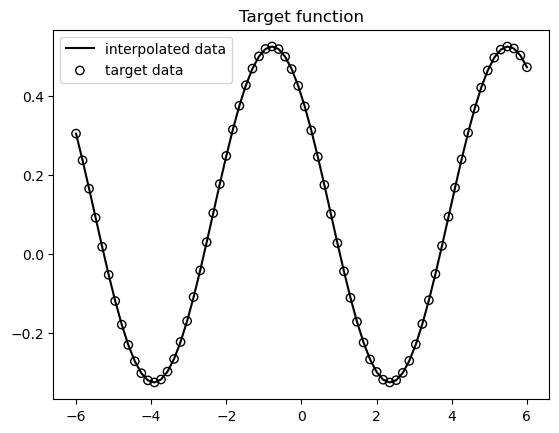

In [14]:
x = np.linspace(-6, 6, 70, requires_grad=False)
target_y = np.array([target_function(x_) for x_ in x], requires_grad=False)

plt.plot(x, target_y, c="black", label="interpolated data")
plt.scatter(x, target_y, facecolors='none', edgecolor="black", label="target data")
#plt.ylim(-1, 1)
plt.legend(loc="best")
plt.title("Target function")
plt.show()

In [15]:
scaling = 1

dev = qml.device("default.qubit", wires=4)

def S(x):
    """Data-encoding circuit block."""
    qml.RX(x, wires=0)

def W(theta):
    """Trainable circuit block."""
    qml.Rot(theta[0], theta[1], theta[2], wires=0)

@qml.qnode(dev)
def serial_quantum_model(weights, x):

    for theta in weights[:-1]:
        W(theta)
        S(x)

    W(weights[-1])

    return qml.expval(qml.PauliZ(wires=0))

$$
\text{Output of the quantum circuit:}\qquad \langle \psi | Z | \psi\rangle
$$

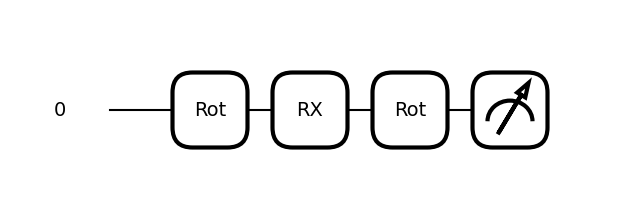

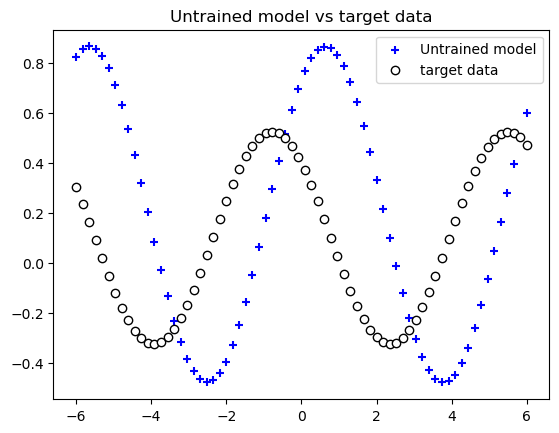

In [17]:
r = 1  # number of times the encoding gets repeated (here equal to the number of layers)
weights = (2 * np.pi * np.random.random(size=(r + 1, 3), requires_grad=True))  # random initial weights

x = np.linspace(-6, 6, 70, requires_grad=False)

qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(serial_quantum_model)(weights, x)
plt.show()

random_quantum_model_y = [serial_quantum_model(weights, x_) for x_ in x]

plt.scatter(x, random_quantum_model_y, marker="+", c="blue", label="Untrained model")
plt.scatter(x, target_y, facecolor="white", edgecolor="black", label="target data")
plt.legend(loc="best")
#plt.ylim(-1, 1)
plt.title("Untrained model vs target data")
plt.show()

Cost at step  20: 0.0018339256590531488
Cost at step  40: 0.0006684606668243108
Cost at step  60: 0.0001280210736629734
Cost at step  80: 9.4823118135866e-06
Cost at step 100: 6.249803028309557e-07
Cost at step 120: 6.592656583305444e-08
Cost at step 140: 2.7798226493898398e-08
Cost at step 160: 3.231574304418369e-09
Cost at step 180: 4.810453780073979e-10
Cost at step 200: 1.7596765911317538e-10


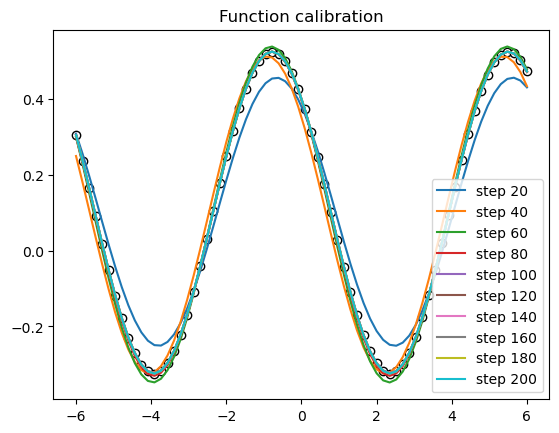

In [18]:
def cost(weights, x, y):
    predictions = [serial_quantum_model(weights, x_) for x_ in x]
    return loss_function(y, predictions)

max_steps = 200
nbsteps_print = 20

opt = qml.AdamOptimizer(0.3)
batch_size = 25
cst = [cost(weights, x, target_y)]  # initial cost

plt.scatter(x, target_y, facecolor="white", edgecolor="black")

for step in range(max_steps):

    # Select batch of data
    batch_index = np.random.randint(0, len(x), (batch_size,))
    x_batch = x[batch_index]
    y_batch = target_y[batch_index]

    # Update the weights by one optimizer step
    weights, _, _ = opt.step(cost, weights, x_batch, y_batch)

    # Save, and possibly print, the current cost
    c = cost(weights, x, target_y)
    cst.append(c)
    if (step + 1) % nbsteps_print == 0:
        print("Cost at step {0:3}: {1}".format(step + 1, c))

        predictions = [serial_quantum_model(weights, x_) for x_ in x]
        plt.plot(x, predictions, label="step %s" %str(step+1))
#plt.ylim(-1, 1)
plt.legend(loc="best")
plt.title("Function calibration")
plt.show()

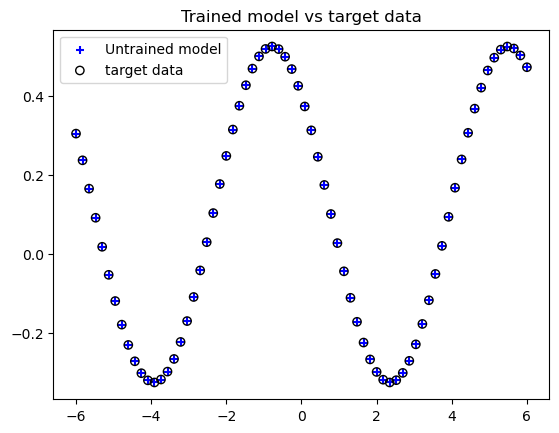

In [19]:
plt.scatter(x, predictions, marker="+", c="blue", label="Untrained model")
plt.scatter(x, target_y, facecolors='none', edgecolor="black", label="target data")
plt.legend(loc="best")
plt.title("Trained model vs target data")
plt.show()

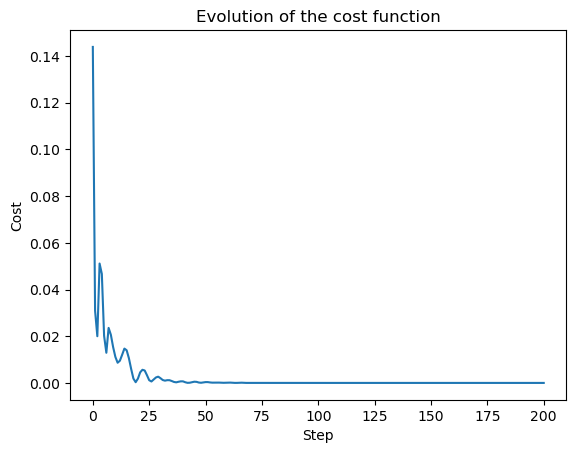

In [20]:
plt.plot(range(len(cst)), cst)
plt.ylabel("Cost")
plt.xlabel("Step")
plt.title("Evolution of the cost function")
plt.show()

## Note: defining a function via a Quantum circuit

\begin{align*}
\mathtt{R}_{\mathtt{X}}(\theta) \mathtt{R}_{\mathtt{X}}(x)\ket{0}
&  = \exp\left(-\frac{\mathrm{i}\theta}{2}\mathtt{X}\right)\exp\left(-\frac{\mathrm{i}x}{2}\mathtt{X}\right)\ket{0}\\
&  = \left\{\cos\left(\frac{\theta}{2}\right)\mathtt{I}  - \mathrm{i}\sin\left(\frac{\theta}{2}\right)\mathtt{X}\right\}\left\{\cos\left(\frac{x}{2}\right)\mathtt{I}  - \mathrm{i}\sin\left(\frac{x}{2}\right)\mathtt{X}\right\}\ket{0}\\
&  = \left\{\cos\left(\frac{\theta}{2}\right)\mathtt{I}  - \mathrm{i}\sin\left(\frac{\theta}{2}\right)\mathtt{X}\right\}\left\{\cos\left(\frac{x}{2}\right)\ket{0}  - \mathrm{i}\sin\left(\frac{x}{2}\right)\ket{1}\right\}\\
&  = \left\{\cos\left(\frac{\theta}{2}\right)\cos\left(\frac{x}{2}\right)
- \sin\left(\frac{\theta}{2}\right)\sin\left(\frac{x}{2}\right)\right\}\ket{0}
- \mathrm{i}\left\{\cos\left(\frac{\theta}{2}\right)\sin\left(\frac{x}{2}\right)
 + \sin\left(\frac{\theta}{2}\right)\cos\left(\frac{x}{2}\right)\right\}\ket{1}\\
&  = \cos\left(\frac{\theta+x}{2}\right)\ket{0}
- \mathrm{i}\sin\left(\frac{\theta+x}{2}\right)\ket{1}\\
 & = f(x,\theta)\ket{0} + \sqrt{1-|f(x,\theta)|^2}\ket{1},
\end{align*}

with
$\displaystyle 
f(x,\theta) := \cos\left(\frac{\theta+x}{2}\right)$.